In [44]:
!pip install torch torchvision scikit-learn matplotlib seaborn

In [45]:
# تحويل الصور لـ tensors + normalization

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# تحميل الداتا

full_train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

# تقسيم train و validation

train_size = int(0.8 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size]
)

# DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Dataset loaded successfully")

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]

Dataset loaded successfully


In [46]:
class MLPModel(nn.Module):

    def __init__(self):
        super(MLPModel, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(28 * 28, 128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        # flatten
        x = x.view(x.size(0), -1)

        return self.model(x)

In [47]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MLPModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(device)

cpu


In [48]:
train_losses = []
validation_losses = []
accuracies = []

epochs = 5

for epoch in range(epochs):

    # Training
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # Validation
    model.eval()

    validation_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    validation_loss /= len(validation_loader)

    validation_losses.append(validation_loss)

    accuracy = 100 * correct / total

    accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {validation_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")
    print("-" * 30)

Epoch 1/5
Train Loss: 0.3187
Validation Loss: 0.1910
Accuracy: 94.19%
------------------------------
Epoch 2/5
Train Loss: 0.1556
Validation Loss: 0.1328
Accuracy: 96.20%
------------------------------
Epoch 3/5
Train Loss: 0.1178
Validation Loss: 0.1205
Accuracy: 96.43%
------------------------------
Epoch 4/5
Train Loss: 0.0975
Validation Loss: 0.1216
Accuracy: 96.53%
------------------------------
Epoch 5/5
Train Loss: 0.0835
Validation Loss: 0.1131
Accuracy: 96.76%
------------------------------


In [49]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.18%


In [50]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[ 970    0    0    0    0    1    3    1    3    2]
 [   0 1125    3    1    0    0    2    0    4    0]
 [   9    2  998    0    2    0    3    7   11    0]
 [   1    0    4  974    0    4    0    7   13    7]
 [   1    0    2    0  953    0    4    1    0   21]
 [   2    1    0    8    2  853    7    0   13    6]
 [   5    3    0    1    6    3  935    0    5    0]
 [   2    5   12    2    0    0    0  981    4   22]
 [   3    2    3    2    6    1    2    4  945    6]
 [   2    3    0    3    7    2    1    5    2  984]]


In [51]:
report = classification_report(
    all_labels,
    all_predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.99      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.95      0.96      1028
           8       0.94      0.97      0.96       974
           9       0.94      0.98      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



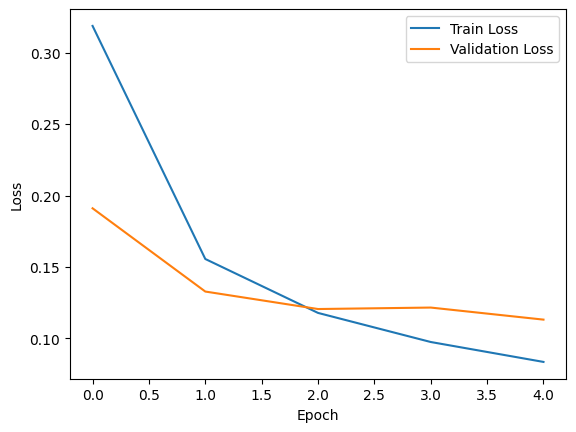

In [52]:
plt.plot(train_losses, label='Train Loss')
plt.plot(validation_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

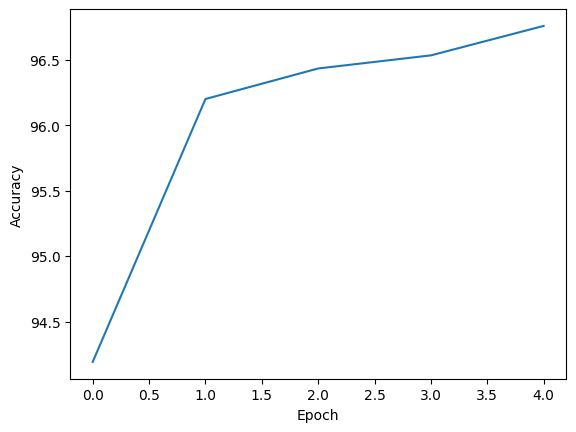

In [53]:
plt.plot(accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

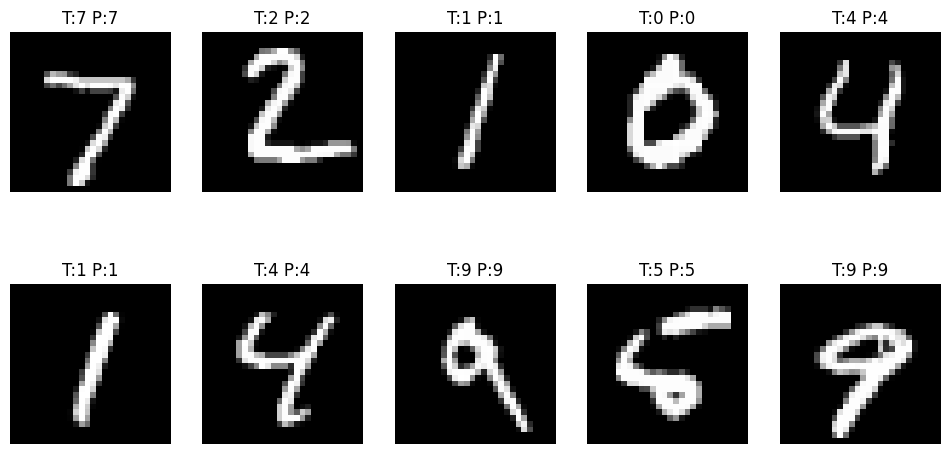

In [54]:
images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predictions = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(
        f"T:{labels[i]} P:{predictions[i].item()}"
    )

    plt.axis('off')

plt.show()

In [55]:
# =========================
# Experiment 2
# =========================

print("Starting Experiment 2")

# New model with:
# - Tanh activation
# - 256 neurons

class MLPModel2(nn.Module):

    def __init__(self):
        super(MLPModel2, self).__init__()

        self.model = nn.Sequential(

            # Hidden layer with 256 neurons
            nn.Linear(28 * 28, 256),

            # Tanh activation function
            nn.Tanh(),

            # Dropout
            nn.Dropout(0.2),

            # Output layer
            nn.Linear(256, 10)
        )

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        return self.model(x)


# Create model
model2 = MLPModel2().to(device)

# Loss function
criterion2 = nn.CrossEntropyLoss()

# Optimizer with different learning rate
optimizer2 = optim.Adam(
    model2.parameters(),
    lr=0.01
)

# Store results
train_losses_2 = []
validation_losses_2 = []
accuracies_2 = []

epochs = 5

# Training loop
for epoch in range(epochs):

    # Training mode
    model2.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses_2.append(train_loss)

    # Validation
    model2.eval()

    validation_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion2(outputs, labels)

            validation_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    validation_loss /= len(validation_loader)

    validation_losses_2.append(validation_loss)

    accuracy = 100 * correct / total

    accuracies_2.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {validation_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")
    print("-" * 30)

# =========================
# Test Evaluation
# =========================

model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy_2 = 100 * correct / total

print(f"Experiment 2 Test Accuracy: {test_accuracy_2:.2f}%")

Starting Experiment 2
Epoch 1/5
Train Loss: 0.4760
Validation Loss: 0.3469
Accuracy: 89.72%
------------------------------
Epoch 2/5
Train Loss: 0.4225
Validation Loss: 0.3005
Accuracy: 91.65%
------------------------------
Epoch 3/5
Train Loss: 0.3994
Validation Loss: 0.3425
Accuracy: 90.29%
------------------------------
Epoch 4/5
Train Loss: 0.3939
Validation Loss: 0.2983
Accuracy: 92.22%
------------------------------
Epoch 5/5
Train Loss: 0.3751
Validation Loss: 0.3493
Accuracy: 90.91%
------------------------------
Experiment 2 Test Accuracy: 91.43%


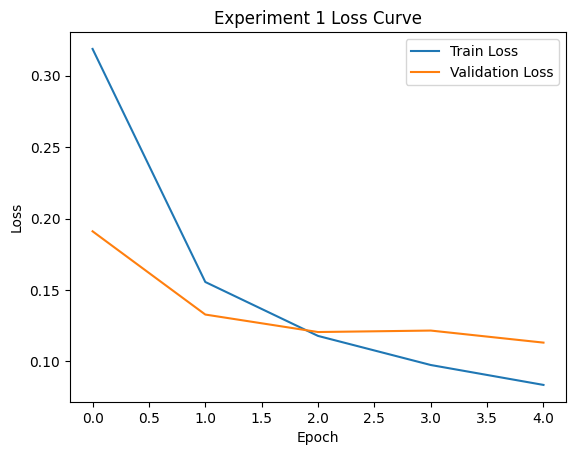

In [56]:
plt.plot(train_losses, label='Train Loss')
plt.plot(validation_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Experiment 1 Loss Curve")

plt.legend()

plt.show()

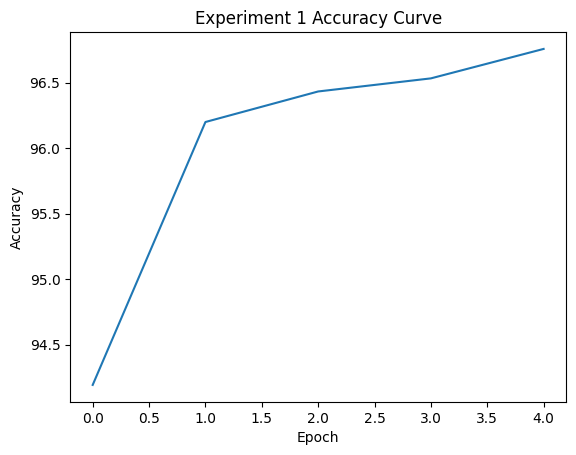

In [57]:
plt.plot(accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Experiment 1 Accuracy Curve")

plt.show()

In [58]:
plt.savefig("loss_curve.png")

<Figure size 640x480 with 0 Axes>

In [59]:
model.eval()

# لحساب الـ loss
test_loss = 0.0

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # توقعات الموديل
        outputs = model(images)

        # حساب الـ loss
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        # استخراج أعلى احتمال
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# حساب المتوسط النهائي للـ loss
final_test_loss = test_loss / len(test_loader)

# حساب الـ accuracy
test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

print(f"Final Test Loss: {final_test_loss:.4f}")

Test Accuracy: 97.18%
Final Test Loss: 0.0884


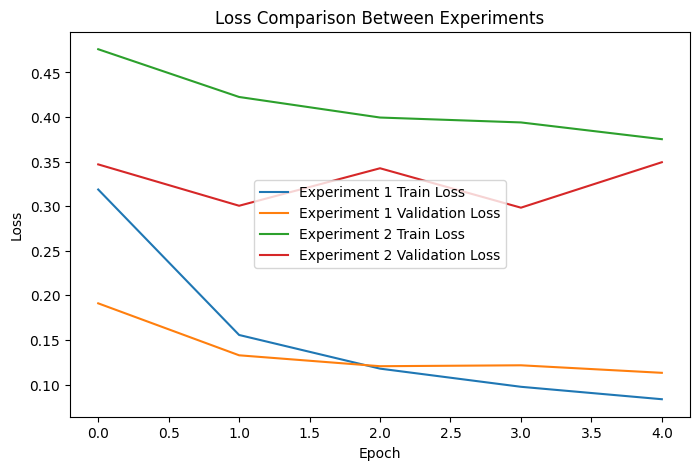

In [60]:
plt.figure(figsize=(8,5))

# Experiment 1
plt.plot(
    train_losses,
    label='Experiment 1 Train Loss'
)

plt.plot(
    validation_losses,
    label='Experiment 1 Validation Loss'
)

# Experiment 2
plt.plot(
    train_losses_2,
    label='Experiment 2 Train Loss'
)

plt.plot(
    validation_losses_2,
    label='Experiment 2 Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Comparison Between Experiments")

plt.legend()

plt.show()

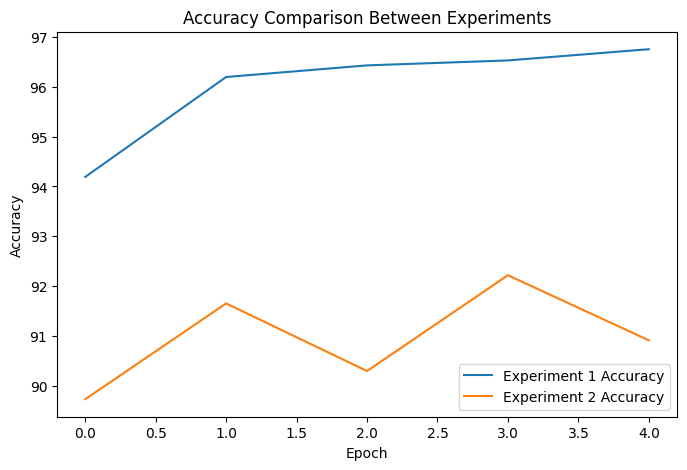

In [61]:
plt.figure(figsize=(8,5))

# Experiment 1
plt.plot(
    accuracies,
    label='Experiment 1 Accuracy'
)

# Experiment 2
plt.plot(
    accuracies_2,
    label='Experiment 2 Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison Between Experiments")

plt.legend()

plt.show()